# 06 · Anàlisi temporal — Població, violència i expansió territorial

**Fonts** (outputs dels notebooks 01–05, a `data/clean/`):
- `population_final.csv` — població dels assentaments, 1993–2025 (Peace Now + JVL)
- `demolitions_wb.csv` — demolicions d'habitatges palestins, 2006–2026
- `fatalities_settlers_wb.csv` — palestins morts a mans de colons, 2000–2026
- `wb_daily_post7o.csv` / `wb_daily_post7o_daily.csv` — sèrie post-7 d'octubre, mensual i diària
- `outposts_points.csv` — outposts amb any de fundació, 1996–2026
- `settlements_points.csv` — assentaments amb any de fundació (només per a la comparativa de la Secció F)

**Objectiu:** identificar patrons temporals, canvis de tendència i comparacions descriptives
— **no** s'infereix causalitat enlloc d'aquest notebook.

**Outputs** (a `data/clean/`):
1. `population_annual_summary.csv`
2. `demolitions_annual_summary.csv`
3. `demolitions_district_summary.csv`
4. `fatalities_annual_summary.csv`
5. `fatalities_district_summary.csv`
6. `outposts_annual_summary.csv`
7. `settlements_vs_outposts_founding.csv`
8. `post7o_period_comparison.csv`
9. `master_annual_summary.csv`

**Fora d'abast:** cap mapa — es construeixen íntegrament al notebook 07.


## 1. Importació de llibreries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import os

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
COLOR_SETTLEMENT = "#D9827A"  
COLOR_OUTPOST    = "#C44E52"  
COLOR_DEMOLITION = "#8B2E2E"   
COLOR_FATALITY   = "#4A1414"  

print("Llibreries carregades correctament")

Llibreries carregades correctament


## 2. Configuració de paths

In [2]:
CLEAN = "data/clean"

FILE_POPULATION  = f"{CLEAN}/population_final.csv"
FILE_DEMOLITIONS = f"{CLEAN}/demolitions_wb.csv"
FILE_FATALITIES  = f"{CLEAN}/fatalities_settlers_wb.csv"
FILE_POST7O_M    = f"{CLEAN}/wb_daily_post7o.csv"
FILE_POST7O_D    = f"{CLEAN}/wb_daily_post7o_daily.csv"
FILE_OUTPOSTS    = f"{CLEAN}/outposts_points.csv"
FILE_SETTLEMENTS = f"{CLEAN}/settlements_points.csv"

OUT_POP_ANNUAL      = f"{CLEAN}/population_annual_summary.csv"
OUT_DEM_ANNUAL       = f"{CLEAN}/demolitions_annual_summary.csv"
OUT_DEM_DISTRICT     = f"{CLEAN}/demolitions_district_summary.csv"
OUT_FAT_ANNUAL        = f"{CLEAN}/fatalities_annual_summary.csv"
OUT_FAT_DISTRICT      = f"{CLEAN}/fatalities_district_summary.csv"
OUT_OUT_ANNUAL         = f"{CLEAN}/outposts_annual_summary.csv"
OUT_FOUNDING_COMPARE   = f"{CLEAN}/settlements_vs_outposts_founding.csv"
OUT_PERIOD_COMPARISON  = f"{CLEAN}/post7o_period_comparison.csv"
OUT_MASTER_ANNUAL      = f"{CLEAN}/master_annual_summary.csv"

OCT7 = pd.Timestamp("2023-10-07")

os.makedirs(CLEAN, exist_ok=True)
print("Paths configurats:", os.path.abspath(CLEAN))

Paths configurats: c:\Users\a-iba\OneDrive\Documentos\Sprint13\Notebook\data\clean


---
## Secció A — Evolució de la població dels assentaments (1993–2025)


In [3]:
df_pop = pd.read_csv(FILE_POPULATION)
print(f"Shape: {df_pop.shape}")
print(f"Rang anys: {df_pop['year'].min()}–{df_pop['year'].max()}")
print(f"\nFonts:\n{df_pop['source'].value_counts()}")

Shape: (4008, 4)
Rang anys: 1993–2025

Fonts:
source
peace_now    3861
jvl           147
Name: count, dtype: int64


In [4]:
pop_annual = (
    df_pop.groupby("year")
    .agg(n_settlements=("settlement", "count"), total_population=("population", "sum"))
    .reset_index()
)
pop_annual["yoy_growth_pct"] = pop_annual["total_population"].pct_change() * 100

print(pop_annual.round(1).to_string(index=False))

 year  n_settlements  total_population  yoy_growth_pct
 1993            105            110066             NaN
 1994            110            124005            12.7
 1995            110            137466            10.9
 1996            116            139453             1.4
 1997            116            152277             9.2
 1998            118            165540             8.7
 1999            118            174405             5.4
 2000            118            191125             9.6
 2001            118            201674             5.5
 2002            118            212218             5.2
 2003            119            221898             4.6
 2004            118            233471             5.2
 2005            119            247230             5.9
 2006            119            261537             5.8
 2007            119            276045             5.5
 2008            119            290311             5.2
 2009            121            297386             2.4
 2010     

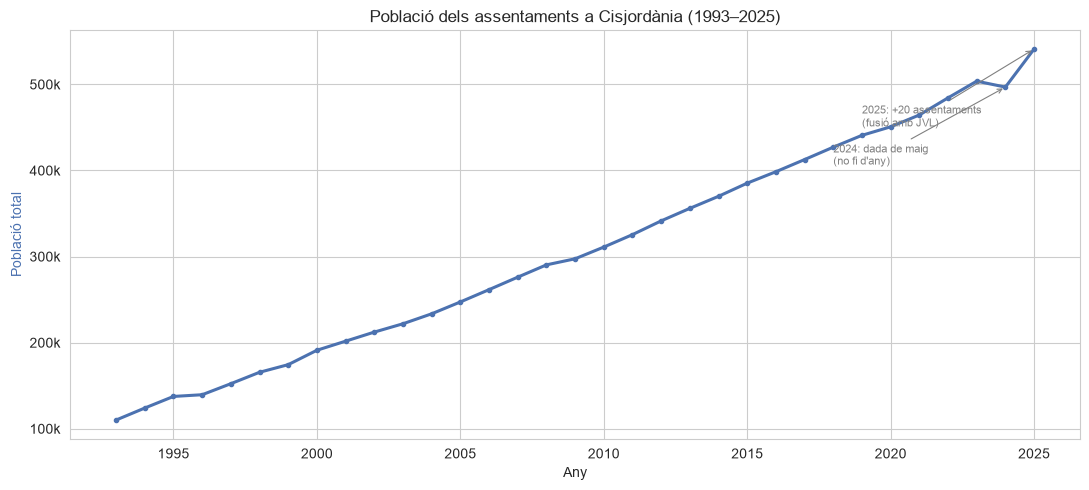

In [5]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(pop_annual["year"], pop_annual["total_population"], color=COLOR_SETTLEMENT, linewidth=2.2, marker="o", markersize=3)
ax1.set_ylabel("Població total", color=COLOR_SETTLEMENT)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax1.set_xlabel("Any")
ax1.set_title("Població dels assentaments a Cisjordània (1993–2025)")

# Marcar els dos anys amb salt metodològic
for yr, label in [(2024, "2024: dada de maig\n(no fi d'any)"), (2025, "2025: +20 assentaments\n(fusió amb JVL)")]:
    val = pop_annual.loc[pop_annual["year"] == yr, "total_population"].values[0]
    ax1.annotate(label, xy=(yr, val), xytext=(yr - 6, val - 90000),
                 fontsize=8, color="gray", arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))

plt.tight_layout()
plt.show()

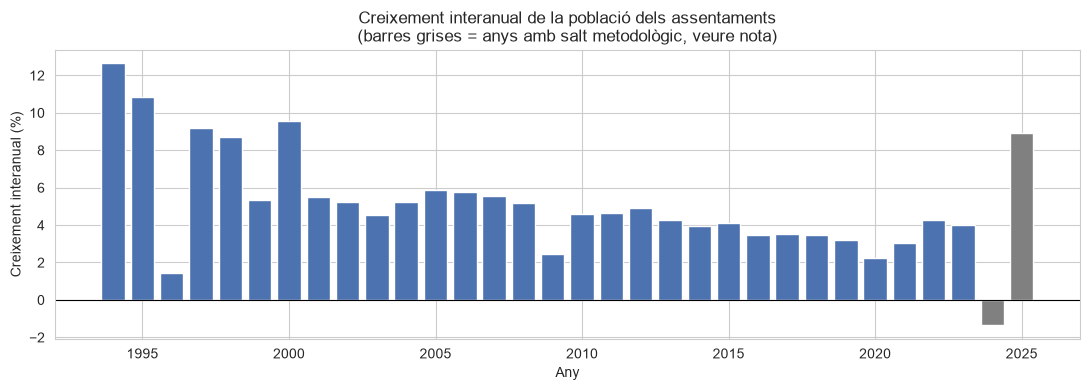

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
colors = ["gray" if yr in (2024, 2025) else COLOR_SETTLEMENT for yr in pop_annual["year"]]
ax.bar(pop_annual["year"], pop_annual["yoy_growth_pct"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Creixement interanual (%)")
ax.set_xlabel("Any")
ax.set_title("Creixement interanual de la població dels assentaments\n(barres grises = anys amb salt metodològic, veure nota)")
plt.tight_layout()
plt.show()

**Patró detectat:** el creixement interanual és notablement estable entre 1996 i 2023,
sempre entre el +3% i el +9%, sense cap any de decreixement. Això contrasta amb la caiguda
aparent de 2024 (−1,4%), que **no és un canvi de tendència real**: la font documenta aquest
any amb dades de maig (`Population May 2024`), no de tancament d'any, cosa que trenca la
comparabilitat directa. De la mateixa manera, el salt de 2025 (+8,9%) és parcialment
compositiu: la fusió amb JVL incorpora 20 assentaments nous al recompte (127→147) que abans
no hi eren, no necessàriament un creixement real d'aquesta magnitud en un sol any. Cal
documentar aquestes dues discontinuïtats a la presentació per no llegir-les com a
acceleració real del creixement poblacional.


In [7]:
pop_annual.to_csv(OUT_POP_ANNUAL, index=False)
print(f"✓ {OUT_POP_ANNUAL}")
print(f"  {len(pop_annual)} anys")

✓ data/clean/population_annual_summary.csv
  33 anys


---
## Secció B — Evolució anual de les demolicions (2006–2026)


In [8]:
df_dem = pd.read_csv(FILE_DEMOLITIONS, parse_dates=["date"])
print(f"Shape: {df_dem.shape}")
print(f"Rang: {df_dem['date'].min().date()} – {df_dem['date'].max().date()}")

Shape: (5465, 10)
Rang: 2006-01-04 – 2026-05-31


In [9]:
dem_annual = (
    df_dem.groupby("year")
    .agg(n_demolitions=("locality", "count"),
         housing_units=("housing_units", "sum"),
         people_homeless=("people_homeless", "sum"),
         minors_homeless=("minors_homeless", "sum"))
    .reset_index()
)
print(dem_annual.to_string(index=False))

 year  n_demolitions  housing_units  people_homeless  minors_homeless
 2006             47             49              225               78
 2007             27             41              267              126
 2008             29             44              276              160
 2009             28             28              218               62
 2010             71             85              387              184
 2011            131            157              853              407
 2012            167            270              526              274
 2013            246            420              532              272
 2014            236            341              729              395
 2015            243            332              506              293
 2016            474            645             1174              600
 2017            157            208              366              203
 2018            160            195              242              121
 2019            201

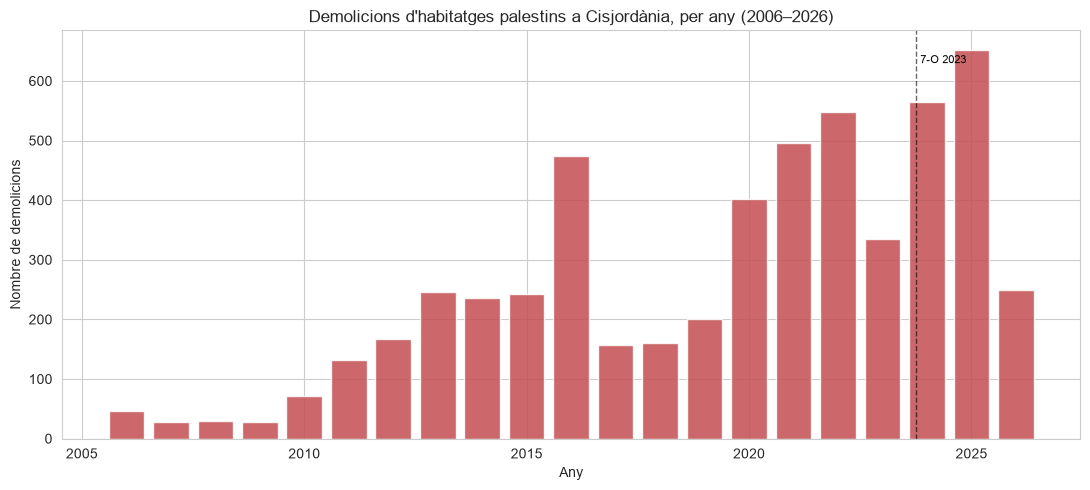

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(dem_annual["year"], dem_annual["n_demolitions"], color=COLOR_DEMOLITION, alpha=0.85)
ax.set_ylabel("Nombre de demolicions")
ax.set_xlabel("Any")
ax.set_title("Demolicions d'habitatges palestins a Cisjordània, per any (2006–2026)")
ax.axvline(2023.75, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.text(2023.85, ax.get_ylim()[1]*0.92, "7-O 2023", fontsize=8, color="black")
plt.tight_layout()
plt.show()

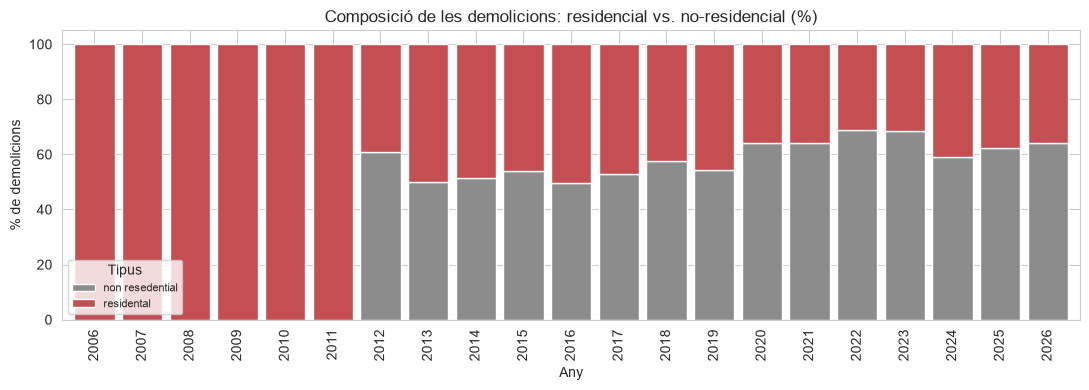

In [11]:
# Composició residencial vs no-residencial al llarg del temps (evita repetir el mateix gràfic de barres)
dem_type = df_dem.groupby(["year", "structure_type"]).size().unstack(fill_value=0)
dem_type_pct = dem_type.div(dem_type.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 4))
dem_type_pct.plot(kind="bar", stacked=True, ax=ax, color=["#8C8C8C", COLOR_DEMOLITION], width=0.85)
ax.set_ylabel("% de demolicions")
ax.set_xlabel("Any")
ax.set_title("Composició de les demolicions: residencial vs. no-residencial (%)")
ax.legend(title="Tipus", loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

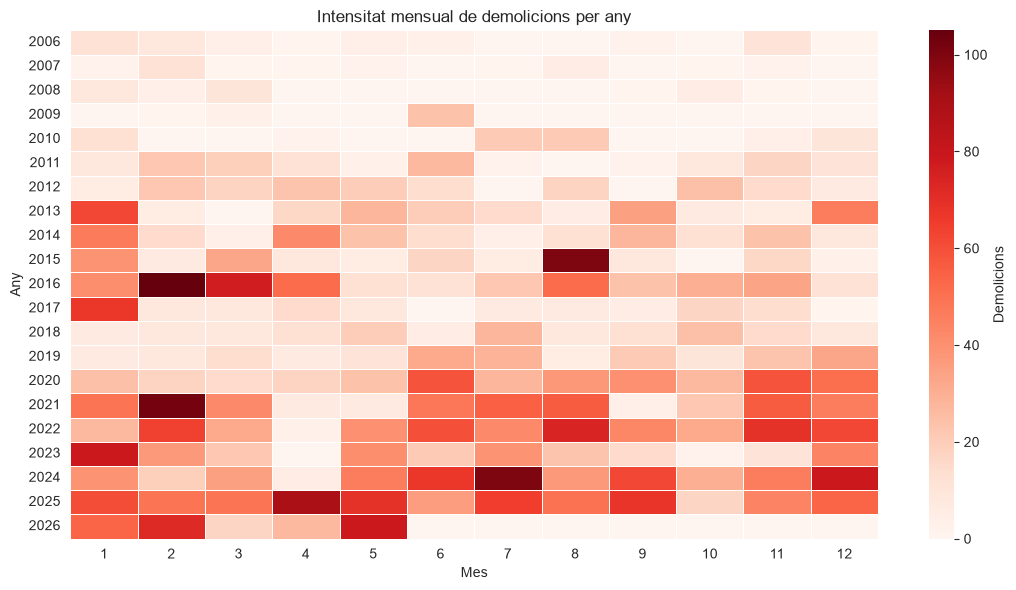

In [12]:
# Heatmap mes x any — mostra estacionalitat i intensificació
dem_heat = df_dem.groupby(["year", "month"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(dem_heat, cmap="Reds", linewidths=0.4, linecolor="white", ax=ax, cbar_kws={"label": "Demolicions"})
ax.set_xlabel("Mes")
ax.set_ylabel("Any")
ax.set_title("Intensitat mensual de demolicions per any")
plt.tight_layout()
plt.show()

            district  n_demolitions  housing_units  people_homeless
              Hebron           1134           1445             2732
             al-Quds            939           1426             1872
               Tubas            772           1324             1678
             Jericho            665           1135             1672
              Nablus            605            868             1170
Ramallah and al-Bira            456            827             1045
           Bethlehem            320            427              620
               Jenin            207            263               96
              Salfit            148            188              159
           Qalqiliya            133            195              150
             Tulkarm             77             98               20
      East Jerusalem              3              3               11
              Israel              2              3                1


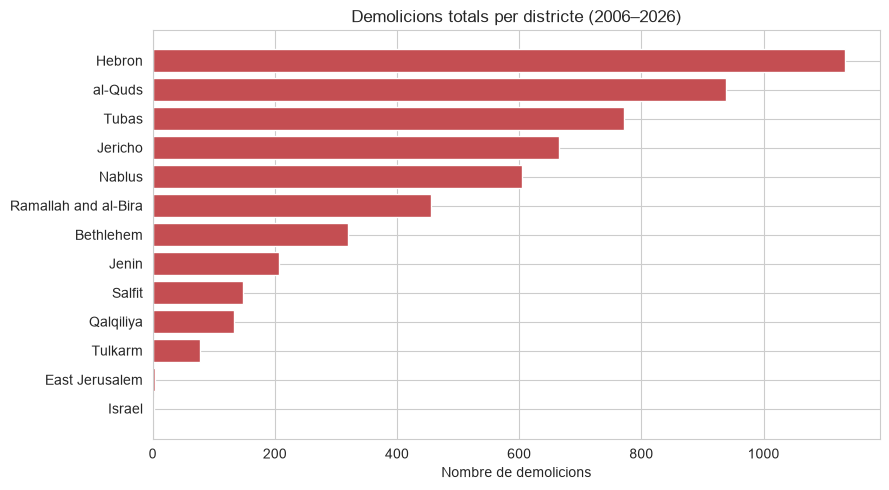

In [13]:
dem_district = (
    df_dem.groupby("district")
    .agg(n_demolitions=("locality", "count"), housing_units=("housing_units", "sum"), people_homeless=("people_homeless", "sum"))
    .reset_index()
    .sort_values("n_demolitions", ascending=False)
)
print(dem_district.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(dem_district["district"][::-1], dem_district["n_demolitions"][::-1], color=COLOR_DEMOLITION)
ax.set_xlabel("Nombre de demolicions")
ax.set_title("Demolicions totals per districte (2006–2026)")
plt.tight_layout()
plt.show()

**Patró detectat:** la sèrie és volàtil any a any però la tendència de fons és clarament
ascendent: dels ~28-47 casos anuals del període 2006–2009 es passa a màxims per sobre de
500 casos/any a partir de 2020 (2022: 548, 2024: 564, 2025: 652 — el màxim de tota la sèrie).
El ritme mensual de demolicions **post-7-O (47,6/mes) és 2,6 vegades el ritme pre-7-O
(18,5/mes)**, tot i que el nivell ja era alt abans de l'octubre de 2023 — no és un fenomen
nou, sinó una intensificació d'una tendència ja en marxa. Hebron i al-Quds concentren la
majoria de casos.


In [14]:
dem_annual.to_csv(OUT_DEM_ANNUAL, index=False)
dem_district.to_csv(OUT_DEM_DISTRICT, index=False)
print(f"✓ {OUT_DEM_ANNUAL}")
print(f"✓ {OUT_DEM_DISTRICT}")

✓ data/clean/demolitions_annual_summary.csv
✓ data/clean/demolitions_district_summary.csv


---
## Secció C — Evolució anual de les víctimes palestines mortes a mans de colons (2000–2026)


In [15]:
df_fat = pd.read_csv(FILE_FATALITIES, parse_dates=["date_event"])
print(f"Shape: {df_fat.shape}")
print(f"Rang: {df_fat['date_event'].min().date()} – {df_fat['date_event'].max().date()}")

Shape: (118, 13)
Rang: 2000-10-07 – 2026-04-22


In [16]:
fat_annual = df_fat.groupby("year").size().reset_index(name="n_fatalities")

# Completar anys sense víctimes (no apareixen al groupby si n=0)
all_years = pd.DataFrame({"year": range(fat_annual["year"].min(), fat_annual["year"].max() + 1)})
fat_annual = all_years.merge(fat_annual, on="year", how="left").fillna({"n_fatalities": 0})
fat_annual["n_fatalities"] = fat_annual["n_fatalities"].astype(int)

print(fat_annual.to_string(index=False))

 year  n_fatalities
 2000             5
 2001             7
 2002            11
 2003             6
 2004             2
 2005             6
 2006             0
 2007             0
 2008             3
 2009             1
 2010             2
 2011             2
 2012             0
 2013             0
 2014             1
 2015             9
 2016             4
 2017             3
 2018             4
 2019             2
 2020             0
 2021             2
 2022             5
 2023            14
 2024             8
 2025             9
 2026            12


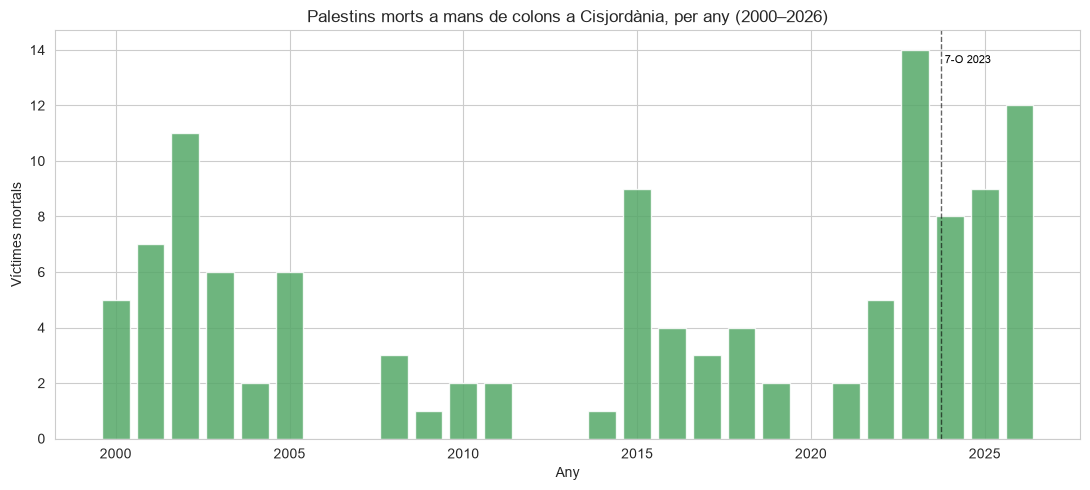

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(fat_annual["year"], fat_annual["n_fatalities"], color=COLOR_FATALITY, alpha=0.85)
ax.set_ylabel("Víctimes mortals")
ax.set_xlabel("Any")
ax.set_title("Palestins morts a mans de colons a Cisjordània, per any (2000–2026)")
ax.axvline(2023.75, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.text(2023.85, ax.get_ylim()[1]*0.92, "7-O 2023", fontsize=8, color="black")
plt.tight_layout()
plt.show()

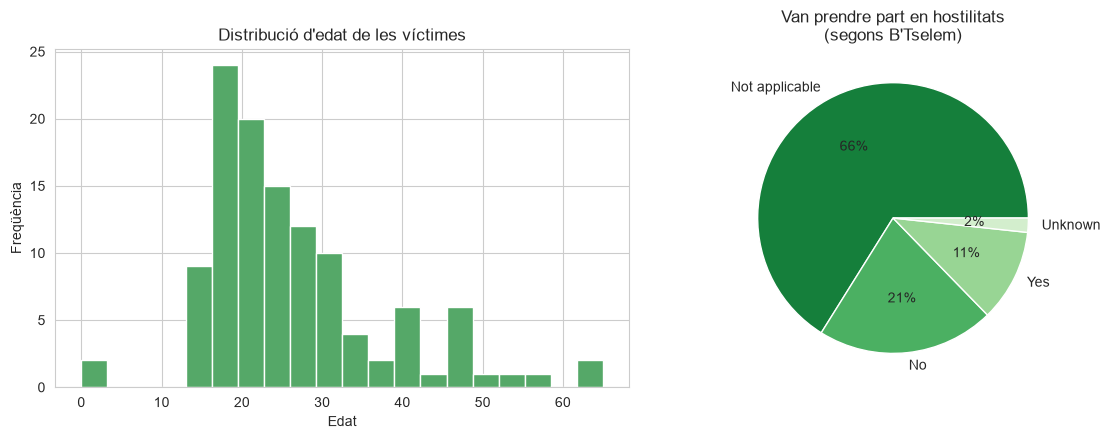

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df_fat["Age"].dropna(), bins=20, color=COLOR_FATALITY, edgecolor="white")
axes[0].set_xlabel("Edat")
axes[0].set_ylabel("Freqüència")
axes[0].set_title("Distribució d'edat de les víctimes")

status = df_fat["civilian_status"].fillna("Unknown").value_counts()
axes[1].pie(status.values, labels=status.index, autopct="%1.0f%%", colors=sns.color_palette("Reds_r", len(status)))
axes[1].set_title("Van prendre part en hostilitats\n(segons B'Tselem)")

plt.tight_layout()
plt.show()

In [2]:
fat_heat = df_fat.groupby(["year", "month"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(fat_heat, cmap="Reds", linewidths=0.4, linecolor="white", ax=ax, cbar_kws={"label": "Víctimes"})
ax.set_xlabel("Mes")
ax.set_ylabel("Any")
ax.set_title("Intensitat mensual de víctimes mortals per any")
plt.tight_layout()
plt.show()

NameError: name 'df_fat' is not defined

In [20]:
fat_district = df_fat.groupby("district").size().reset_index(name="n_fatalities").sort_values("n_fatalities", ascending=False)
print(fat_district.to_string(index=False))

            district  n_fatalities
Ramallah and al-Bira            36
              Nablus            31
              Hebron            22
           Bethlehem            12
              Salfit             4
      East Jerusalem             3
             Tulkarm             3
             al-Quds             3
           Qalqiliya             2
             Jericho             1
               Tubas             1


**Patró detectat:** la distribució és irregular i amb xifres anuals baixes (0–14 casos),
per la qual cosa cal ser prudent a l'hora de parlar de "tendències" en sentit estadístic
estricte. Dit això, la concentració temporal és clara: **2023 (14 casos) i 2026 (12 casos
fins a la data d'extracció) són els dos anys amb més víctimes de tota la sèrie des de 2000**,
i el ritme mensual **post-7-O (1,13/mes) triplica llargament el ritme pre-7-O (0,30/mes)**.
Ramallah i Nablus concentren gairebé el 60% dels casos totals. La majoria de víctimes
`No` van prendre part en hostilitats segons el registre de B'Tselem, tot i que hi ha un
percentatge no menyspreable classificat com `Unknown`.


In [21]:
fat_annual.to_csv(OUT_FAT_ANNUAL, index=False)
fat_district.to_csv(OUT_FAT_DISTRICT, index=False)
print(f"✓ {OUT_FAT_ANNUAL}")
print(f"✓ {OUT_FAT_DISTRICT}")

✓ data/clean/fatalities_annual_summary.csv
✓ data/clean/fatalities_district_summary.csv


---
## Secció D — Sèrie post-7 d'octubre (mensual i diària)

Aquí és on el detall diari aporta valor: la sèrie mensual ja existeix (`wb_daily_post7o.csv`),
però un gràfic interactiu sobre els 1.012 dies permet detectar repunts puntuals que
l'agregació mensual dilueix.


In [22]:
df_post_m = pd.read_csv(FILE_POST7O_M, parse_dates=["date"])
df_post_d = pd.read_csv(FILE_POST7O_D, parse_dates=["date"])

print(f"Mensual: {df_post_m.shape} | {df_post_m['date'].min().date()} – {df_post_m['date'].max().date()}")
print(f"Diari:   {df_post_d.shape} | {df_post_d['date'].min().date()} – {df_post_d['date'].max().date()}")

# El darrer mes pot estar incomplet (data d'extracció a mig mes)
print(f"\nÚltima fila mensual (pot estar incompleta):\n{df_post_m.iloc[-1][['date','deaths_month','settler_attacks_month']]}")

Mensual: (34, 10) | 2023-10-01 – 2026-07-01
Diari:   (1012, 10) | 2023-10-07 – 2026-07-14

Última fila mensual (pot estar incompleta):
date                     2026-07-01 00:00:00
deaths_month                             0.0
settler_attacks_month                    0.0
Name: 33, dtype: object


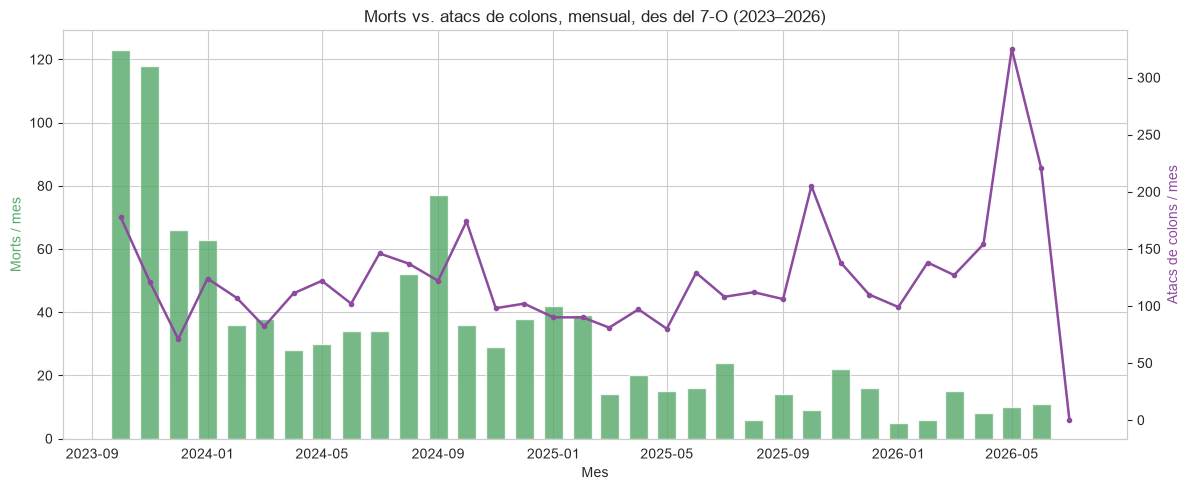

In [23]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(df_post_m["date"], df_post_m["deaths_month"], width=20, color=COLOR_FATALITY, alpha=0.8, label="Morts / mes")
ax1.set_ylabel("Morts / mes", color=COLOR_FATALITY)
ax1.set_xlabel("Mes")

ax2 = ax1.twinx()
ax2.plot(df_post_m["date"], df_post_m["settler_attacks_month"], color="#8C4B9E", marker="o", markersize=3, linewidth=1.8, label="Atacs de colons / mes")
ax2.set_ylabel("Atacs de colons / mes", color="#8C4B9E")
ax2.grid(False)

ax1.set_title("Morts vs. atacs de colons, mensual, des del 7-O (2023–2026)")
fig.tight_layout()
plt.show()

In [24]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_post_d["date"], y=df_post_d["deaths_cum"], name="Morts (acumulat)",
                          line=dict(color="#55A868", width=2)))
fig.add_trace(go.Scatter(x=df_post_d["date"], y=df_post_d["settler_attacks_cum"], name="Atacs de colons (acumulat)",
                          line=dict(color="#8C4B9E", width=2), yaxis="y2"))

fig.update_layout(
    title="Acumulats diaris post-7-O: morts vs. atacs de colons",
    xaxis_title="Data",
    yaxis=dict(title="Morts (acumulat)", tickfont=dict(color="#55A868")),
    yaxis2=dict(title="Atacs de colons (acumulat)", tickfont=dict(color="#8C4B9E"), overlaying="y", side="right"),
    legend=dict(orientation="h", y=1.1),
    height=450,
    template="plotly_white",
)
fig.show()

In [25]:
# Mitjana mòbil de 14 dies dels atacs diaris (derivada de l'acumulat) — suavitza el soroll diari
df_post_d = df_post_d.sort_values("date").reset_index(drop=True)
df_post_d["settler_attacks_daily"] = df_post_d["settler_attacks_cum"].diff().clip(lower=0)
df_post_d["settler_attacks_ma14"] = df_post_d["settler_attacks_daily"].rolling(14, min_periods=7).mean()

fig = px.line(df_post_d, x="date", y="settler_attacks_ma14",
              title="Atacs de colons — mitjana mòbil de 14 dies",
              labels={"settler_attacks_ma14": "Atacs / dia (mitjana mòbil 14d)", "date": "Data"},
              template="plotly_white")
fig.update_traces(line_color="#8C4B9E", line_width=2)
fig.update_layout(height=400)
fig.show()

**Patró detectat:** les dues sèries divergeixen de manera notable. Les morts mensuals
cauen de manera pràcticament monotònica des del pic inicial (123 a l'octubre de 2023) fins
a xifres d'un sol dígit el 2025–2026. Els atacs de colons, en canvi, **es mantenen en un
nivell alt de manera sostinguda i fins i tot repunten amb força** (325 casos al maig de
2026, el màxim de tota la sèrie post-7-O). És a dir: la letalitat baixa, però la freqüència
d'incidents no — un patró rellevant per al storytelling, ja que suggereix que la reducció de
morts no es correspon amb una reducció de la conflictivitat sobre el terreny. Cal notar que
l'últim mes de la sèrie mensual pot estar incomplet (data d'extracció a mig mes).


---
## Secció E — Creació d'outposts al llarg del temps (1996–2026)


In [26]:
df_out = pd.read_csv(FILE_OUTPOSTS)
print(f"Shape: {df_out.shape}")
print(f"Rang any de fundació: {df_out['year_established'].min()}–{df_out['year_established'].max()}")

Shape: (383, 11)
Rang any de fundació: 1996–2026


In [27]:
out_annual = df_out.groupby("year_established").size().reset_index(name="n_new_outposts")
out_annual = out_annual.rename(columns={"year_established": "year"})

all_years_out = pd.DataFrame({"year": range(int(out_annual["year"].min()), int(out_annual["year"].max()) + 1)})
out_annual = all_years_out.merge(out_annual, on="year", how="left").fillna({"n_new_outposts": 0})
out_annual["n_new_outposts"] = out_annual["n_new_outposts"].astype(int)
out_annual["cumulative_outposts"] = out_annual["n_new_outposts"].cumsum()

print(out_annual.to_string(index=False))

 year  n_new_outposts  cumulative_outposts
 1996               4                    4
 1997               3                    7
 1998              13                   20
 1999              11                   31
 2000               1                   32
 2001              17                   49
 2002              18                   67
 2003               2                   69
 2004               3                   72
 2005               1                   73
 2006               0                   73
 2007               0                   73
 2008               2                   75
 2009               0                   75
 2010               0                   75
 2011               0                   75
 2012               5                   80
 2013               3                   83
 2014               4                   87
 2015               1                   88
 2016               3                   91
 2017               4                   95
 2018      

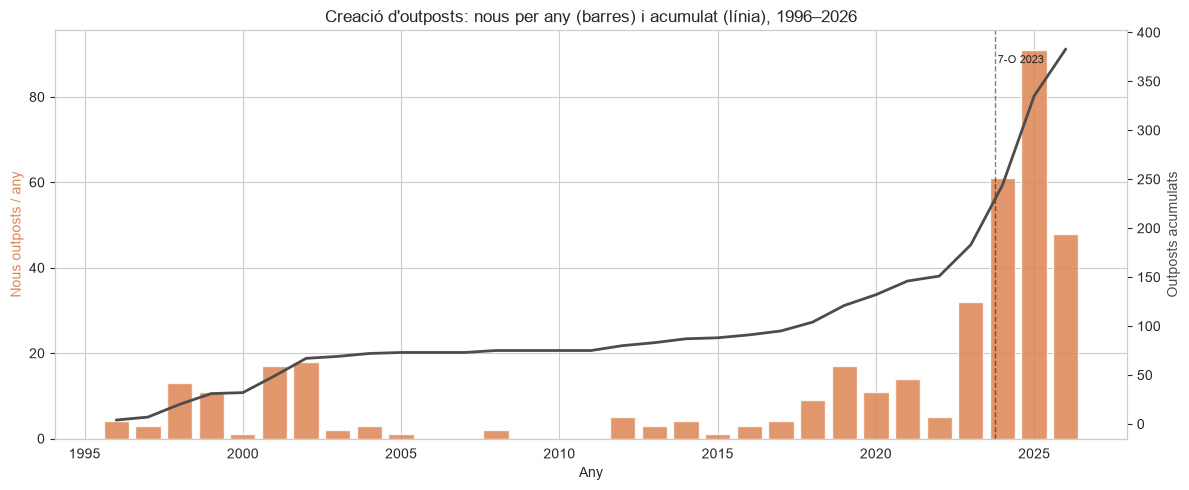

In [28]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(out_annual["year"], out_annual["n_new_outposts"], color=COLOR_OUTPOST, alpha=0.85, label="Nous outposts")
ax1.set_ylabel("Nous outposts / any", color=COLOR_OUTPOST)
ax1.set_xlabel("Any")

ax2 = ax1.twinx()
ax2.plot(out_annual["year"], out_annual["cumulative_outposts"], color="#4C4C4C", linewidth=2, label="Acumulat")
ax2.set_ylabel("Outposts acumulats", color="#4C4C4C")
ax2.grid(False)

ax1.axvline(2023.75, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax1.text(2023.85, ax1.get_ylim()[1]*0.92, "7-O 2023", fontsize=8)

ax1.set_title("Creació d'outposts: nous per any (barres) i acumulat (línia), 1996–2026")
fig.tight_layout()
plt.show()

**Patró detectat:** aquesta és la sèrie amb l'acceleració més clara de tot el dataset.
El ritme de creació d'outposts es manté baix i irregular (1–18/any) entre 1996 i 2022, però
**s'accelera bruscament a partir de 2023: 32 nous outposts el 2023, 61 el 2024 i 91 el 2025**
— gairebé un outpost cada 4 dies de mitjana durant el 2025. El 2026 (48 fins a la data
d'extracció, any incomplet) manté un ritme igualment alt. Més de la meitat de tots els
outposts documentats (335 de 383, un 87%) s'han fundat des de l'1 de gener de 2020.


In [29]:
out_annual.to_csv(OUT_OUT_ANNUAL, index=False)
print(f"✓ {OUT_OUT_ANNUAL}")

✓ data/clean/outposts_annual_summary.csv


---
## Secció F — Valor afegit: assentaments formals vs. outposts informals

**Per què incorporo aquesta comparativa:** és el contrast que millor explica la dinàmica
territorial recent. Els assentaments formals necessiten aprovació governamental; els
outposts no. Comparar-ne els ritmes de fundació mostra un canvi estructural en com avança
l'expansió territorial, no només "quant" avança.


In [30]:
df_settl_geo = pd.read_csv(FILE_SETTLEMENTS)
settl_founding = df_settl_geo.dropna(subset=["year_established"]).copy()
settl_founding["year_established"] = settl_founding["year_established"].astype(int)
settl_annual = settl_founding.groupby("year_established").size().reset_index(name="n_new_settlements")
settl_annual = settl_annual.rename(columns={"year_established": "year"})

founding_compare = out_annual[["year", "n_new_outposts"]].merge(settl_annual, on="year", how="outer").fillna(0)
founding_compare = founding_compare.sort_values("year")
founding_compare[["n_new_settlements", "n_new_outposts"]] = founding_compare[["n_new_settlements", "n_new_outposts"]].astype(int)

print(founding_compare.to_string(index=False))
print(f"\nAssentaments fundats des de 1993: {settl_founding[settl_founding['year_established'] >= 1993].shape[0]}")
print(f"Outposts fundats des de 1993:     {df_out[df_out['year_established'] >= 1993].shape[0]}")

 year  n_new_outposts  n_new_settlements
 1967               0                  1
 1968               0                  3
 1969               0                  1
 1970               0                  6
 1971               0                  2
 1972               0                  3
 1973               0                  2
 1975               0                  4
 1976               0                  2
 1977               0                 15
 1978               0                  7
 1979               0                  4
 1980               0                  7
 1981               0                 15
 1982               0                  9
 1983               0                 16
 1984               0                  8
 1985               0                  8
 1986               0                  1
 1987               0                  1
 1988               0                  1
 1989               0                  4
 1990               0                  2
 1991           

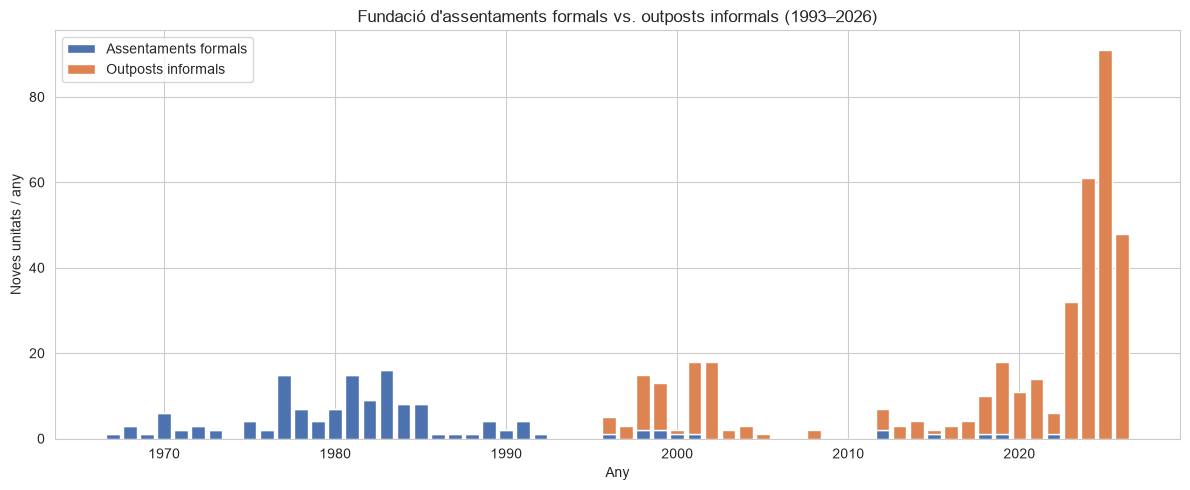

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(founding_compare["year"], founding_compare["n_new_settlements"], color=COLOR_SETTLEMENT, label="Assentaments formals")
ax.bar(founding_compare["year"], founding_compare["n_new_outposts"], bottom=founding_compare["n_new_settlements"],
       color=COLOR_OUTPOST, label="Outposts informals")
ax.set_ylabel("Noves unitats / any")
ax.set_xlabel("Any")
ax.set_title("Fundació d'assentaments formals vs. outposts informals (1993–2026)")
ax.legend()
plt.tight_layout()
plt.show()

**Patró detectat:** la fundació formal d'assentaments pràcticament s'atura després de
1993 (només 8 casos aïllats en 30 anys). Des de llavors, **pràcticament tota l'expansió de
punts d'assentament nous passa pels outposts**, no pels assentaments oficials. Això reforça
la lectura de la Secció E: el creixement de la població (Secció A) es concentra en
assentaments ja existents que s'expandeixen, mentre que l'expansió *territorial* (nous punts
sobre el mapa) es fa gairebé exclusivament via outposts no autoritzats, amb una acceleració
molt marcada després de 2023.


In [32]:
founding_compare.to_csv(OUT_FOUNDING_COMPARE, index=False)
print(f"✓ {OUT_FOUNDING_COMPARE}")

✓ data/clean/settlements_vs_outposts_founding.csv


---
## Secció G — Comparativa de períodes: abans vs. després del 7-O 2023

Taula resum dels ritmes mensuals abans i després del 7 d'octubre de 2023, per a les
variables on té sentit (demolicions, víctimes, outposts). **Purament descriptiu**: cap
d'aquests ritmes es presenta com a efecte causal del 7-O, només com a canvi de nivell
observat en el temps.


In [33]:
def monthly_rate(dates, start, end):
    mask = (dates >= start) & (dates <= end)
    n = mask.sum()
    n_months = (end.to_period("M") - dates[mask].min().to_period("M")).n + 1 if n > 0 else 1
    return n / n_months

rows = []

# Demolicions
pre = monthly_rate(df_dem["date"], df_dem["date"].min(), OCT7 - pd.Timedelta(days=1))
post = monthly_rate(df_dem["date"], OCT7, df_dem["date"].max())
rows.append(["Demolicions (habitatges)", round(pre, 1), round(post, 1), round(post / pre, 2)])

# Víctimes
pre_f = monthly_rate(df_fat["date_event"], df_fat["date_event"].min(), OCT7 - pd.Timedelta(days=1))
post_f = monthly_rate(df_fat["date_event"], OCT7, df_fat["date_event"].max())
rows.append(["Víctimes mortals", round(pre_f, 2), round(post_f, 2), round(post_f / pre_f, 2)])

# Outposts (a partir de l'any de fundació, aproximació a mes = juliol de l'any)
out_dates = pd.to_datetime(df_out["year_established"].astype(int).astype(str) + "-07-01")
pre_o = monthly_rate(out_dates, out_dates.min(), OCT7 - pd.Timedelta(days=1))
post_o = monthly_rate(out_dates, OCT7, out_dates.max())
rows.append(["Nous outposts", round(pre_o, 2), round(post_o, 2), round(post_o / pre_o, 2)])

period_comparison = pd.DataFrame(rows, columns=["metric", "pre_oct7_monthly_rate", "post_oct7_monthly_rate", "ratio_post_vs_pre"])
print(period_comparison.to_string(index=False))

                  metric  pre_oct7_monthly_rate  post_oct7_monthly_rate  ratio_post_vs_pre
Demolicions (habitatges)                  18.40                   47.60               2.58
        Víctimes mortals                   0.30                    1.13               3.77
           Nous outposts                   0.56                    8.00              14.34


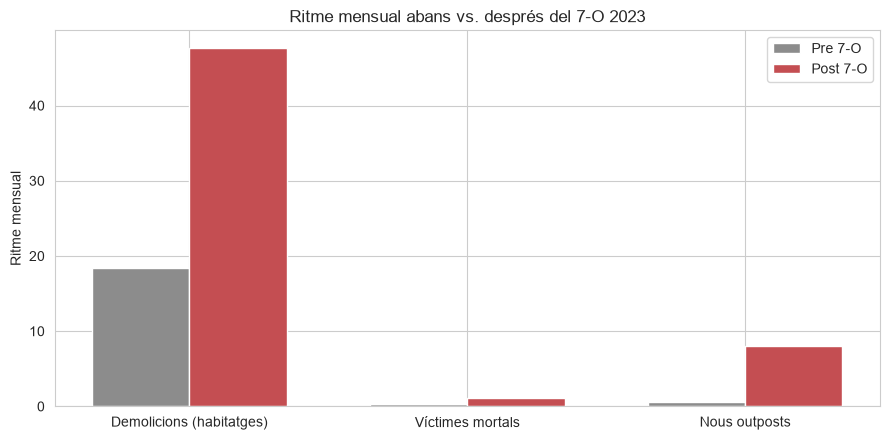

In [34]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(period_comparison))
width = 0.35
ax.bar(x - width/2, period_comparison["pre_oct7_monthly_rate"], width, label="Pre 7-O", color="#8C8C8C")
ax.bar(x + width/2, period_comparison["post_oct7_monthly_rate"], width, label="Post 7-O", color=COLOR_DEMOLITION)
ax.set_xticks(x)
ax.set_xticklabels(period_comparison["metric"])
ax.set_ylabel("Ritme mensual")
ax.set_title("Ritme mensual abans vs. després del 7-O 2023")
ax.legend()
plt.tight_layout()
plt.show()

**Patró detectat:** les tres variables incrementen el seu ritme mensual després del
7-O, però en graus molt diferents: les víctimes mortals es multipliquen per ~3,7, les
demolicions per ~2,6, i els outposts per un factor més moderat perquè ja venien d'una
tendència alcista des de 2018–2019 (l'aproximació a mes de juliol de l'any de fundació és
una simplificació — no hi ha data exacta de fundació al dataset, només l'any).


In [35]:
period_comparison.to_csv(OUT_PERIOD_COMPARISON, index=False)
print(f"✓ {OUT_PERIOD_COMPARISON}")

✓ data/clean/post7o_period_comparison.csv


---
## Secció H — Taula mestra anual (per a Power BI)

Una única taula fet per any, amb les quatre dimensions creuades. Pensada com a taula central
d'un model en estrella a Power BI, evitant haver de fer els joins allà.


In [36]:
master = pop_annual[["year", "total_population", "yoy_growth_pct"]].merge(
    dem_annual[["year", "n_demolitions", "housing_units", "people_homeless"]], on="year", how="outer"
).merge(
    fat_annual[["year", "n_fatalities"]], on="year", how="outer"
).merge(
    out_annual[["year", "n_new_outposts", "cumulative_outposts"]], on="year", how="outer"
).sort_values("year").reset_index(drop=True)

# Emplenar únicament els comptadors d'esdeveniments (no la població, que és un stock, no un flux)
count_cols = ["n_demolitions", "housing_units", "people_homeless", "n_fatalities", "n_new_outposts"]
master[count_cols] = master[count_cols].fillna(0)

print(f"Shape: {master.shape}")
print(master.tail(15).to_string(index=False))

Shape: (34, 9)
 year  total_population  yoy_growth_pct  n_demolitions  housing_units  people_homeless  n_fatalities  n_new_outposts  cumulative_outposts
 2012          341418.0        4.905793          167.0          270.0            526.0           0.0             5.0                 80.0
 2013          355983.0        4.266032          246.0          420.0            532.0           0.0             3.0                 83.0
 2014          369977.0        3.931087          236.0          341.0            729.0           1.0             4.0                 87.0
 2015          385264.0        4.131878          243.0          332.0            506.0           9.0             1.0                 88.0
 2016          398534.0        3.444391          474.0          645.0           1174.0           4.0             3.0                 91.0
 2017          412668.0        3.546498          157.0          208.0            366.0           3.0             4.0                 95.0
 2018          4270

In [37]:
master.to_csv(OUT_MASTER_ANNUAL, index=False)
print(f"✓ {OUT_MASTER_ANNUAL}")
print(f"  {len(master)} anys, {master.shape[1]} columnes")

✓ data/clean/master_annual_summary.csv
  34 anys, 9 columnes


---
## Resum d'outputs

| Fitxer | Contingut |
|---|---|
| `population_annual_summary.csv` | Població total i creixement interanual, per any |
| `demolitions_annual_summary.csv` | Demolicions, unitats i persones desplaçades, per any |
| `demolitions_district_summary.csv` | Demolicions totals per districte |
| `fatalities_annual_summary.csv` | Víctimes mortals, per any (anys sense víctimes inclosos amb 0) |
| `fatalities_district_summary.csv` | Víctimes totals per districte |
| `outposts_annual_summary.csv` | Nous outposts i acumulat, per any |
| `settlements_vs_outposts_founding.csv` | Comparativa de fundació formal vs. informal |
| `post7o_period_comparison.csv` | Ritmes mensuals pre/post 7-O 2023 |
| `master_annual_summary.csv` | Taula fet anual única (població + demolicions + víctimes + outposts) |

**Proper pas:** notebook 07 — mapes interactius, consumint `settlements_points.csv`,
`outposts_points.csv` i, quan estiguin disponibles, les capes de Green Line / Àrees A-B-C /
barrera / checkpoints.
